In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import plotly.express as px
import plotly.graph_objects as go

In [2]:
# Load the dataset
df = pd.read_csv("/content/AQI-and-Lat-Long-of-Countries.csv")

In [3]:
# Display basic information about the dataset
print(df.head())
print(df.info())

   AQI Value  CO AQI Value  Ozone AQI Value  NO2 AQI Value  PM2.5 AQI Value  \
0         51             1               36              0               51   
1         41             1                5              1               41   
2         41             1                5              1               41   
3         66             1               39              2               66   
4         34             1               34              0               20   

       lat      lng  
0  44.7444  44.2031  
1  -5.2900 -44.4900  
2 -11.2958 -41.9869  
3  37.1667  15.1833  
4  53.0167  20.8833  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16695 entries, 0 to 16694
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   AQI Value        16695 non-null  int64  
 1   CO AQI Value     16695 non-null  int64  
 2   Ozone AQI Value  16695 non-null  int64  
 3   NO2 AQI Value    16695 non-null  int64  
 4   PM2.

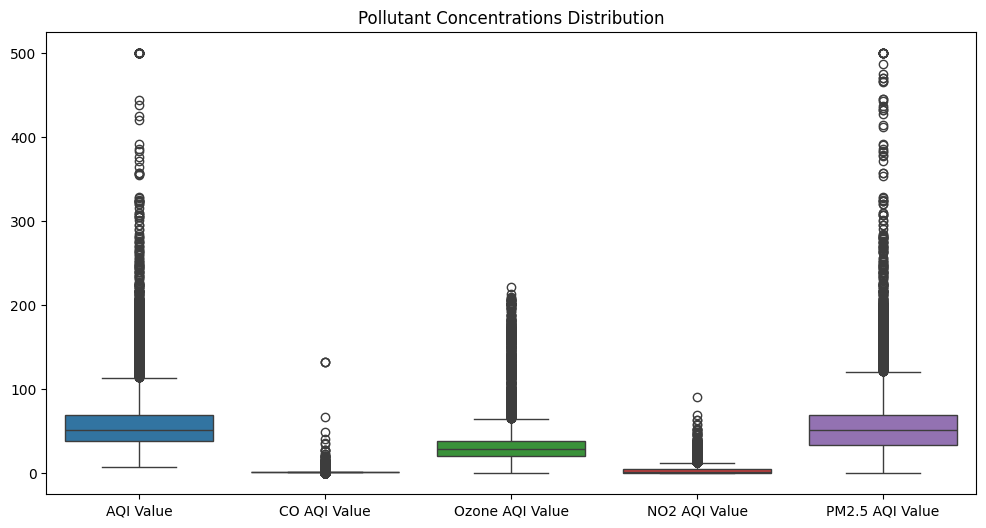

In [4]:
# Exploratory Data Analysis (EDA)
# Plotting pollutant concentrations
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[['AQI Value', 'CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value']])
plt.title('Pollutant Concentrations Distribution')
plt.show()

<Figure size 1400x700 with 0 Axes>

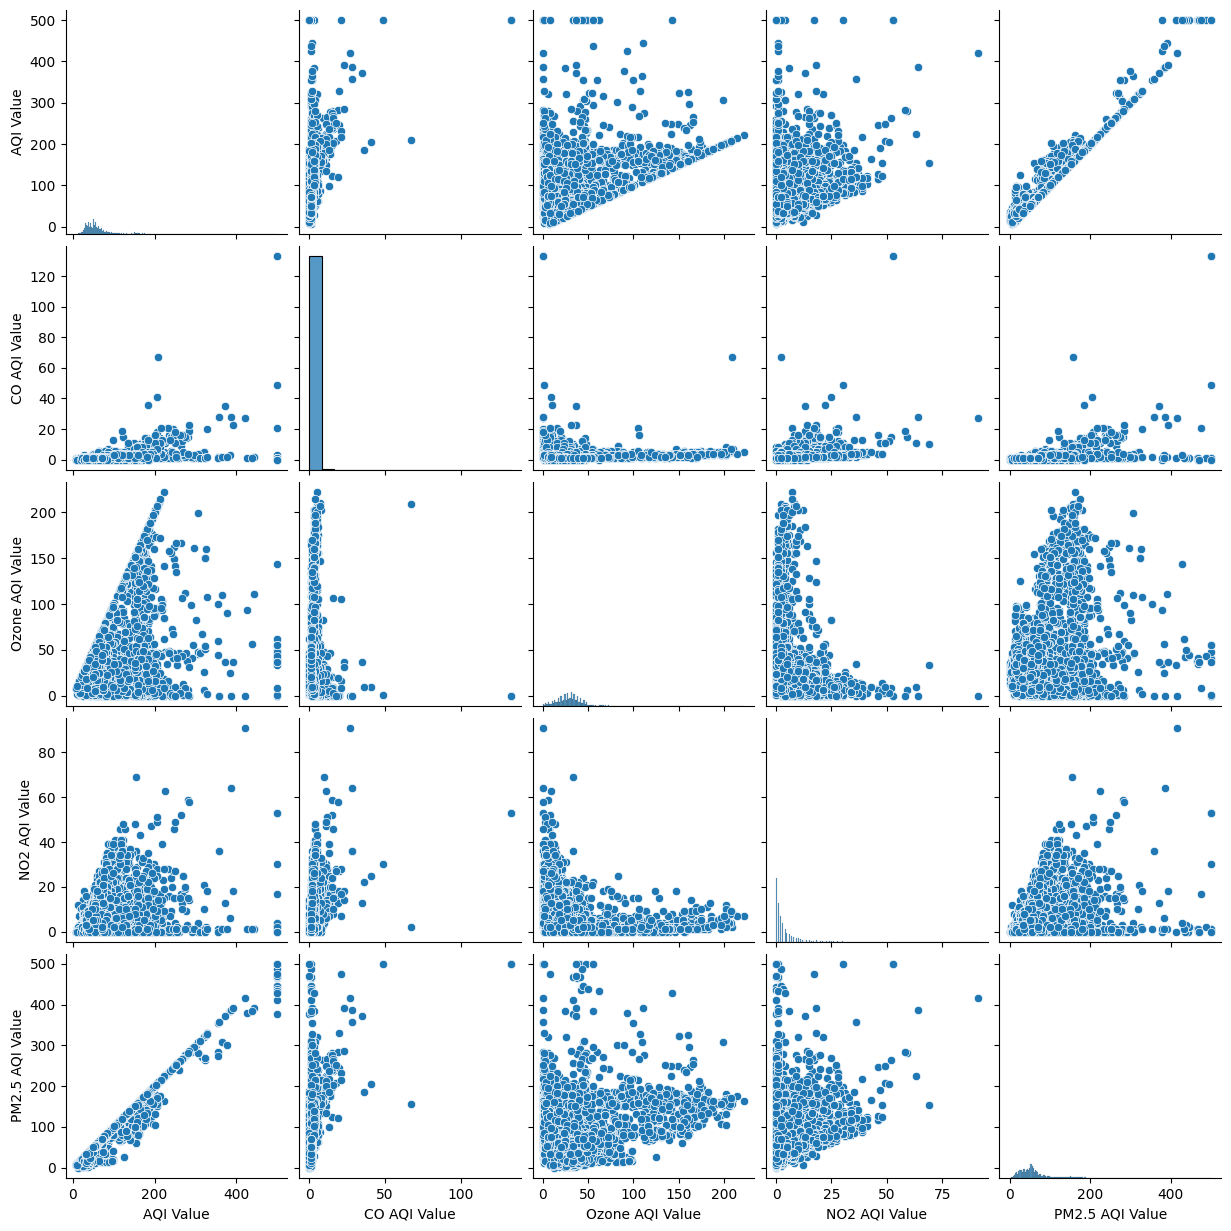

In [5]:
# Visualizing the relationship between pollutants
plt.figure(figsize=(14, 7))
sns.pairplot(df[['AQI Value', 'CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value']])
plt.show()

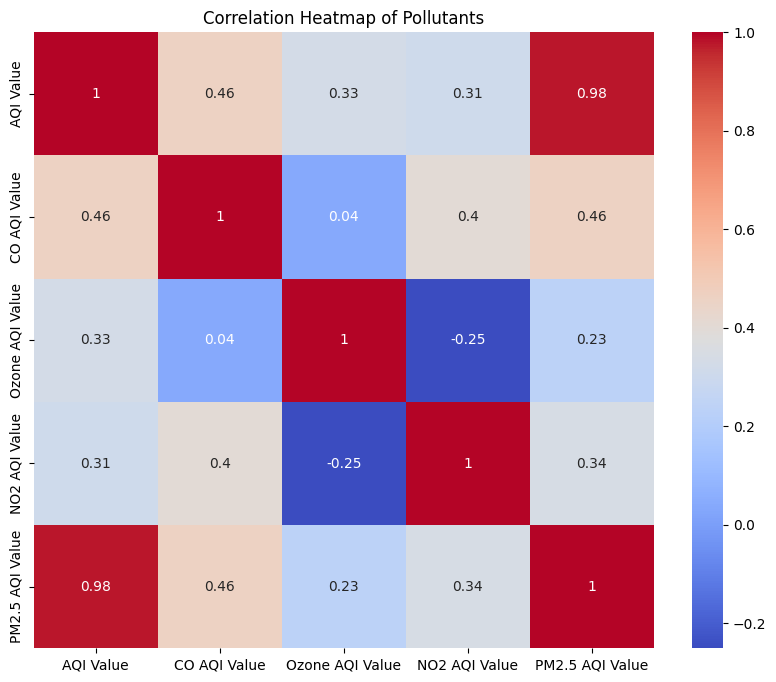

In [6]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df[['AQI Value', 'CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Pollutants')
plt.show()

In [7]:
# Feature Selection - We'll use all the pollutants to predict AQI Value (as an example)
X = df[['CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value']]
y = df['AQI Value']

In [8]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
# Model Building - Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

LinearRegression()

In [11]:
# Model Evaluation - Linear Regression
y_pred_lr = lr.predict(X_test_scaled)
print("Linear Regression - MAE:", mean_absolute_error(y_test, y_pred_lr))
print("Linear Regression - RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("Linear Regression - R²:", r2_score(y_test, y_pred_lr))

Linear Regression - MAE: 4.1765907360691035
Linear Regression - RMSE: 6.504410690902979
Linear Regression - R²: 0.9744908345378135


In [12]:
# Model Building - Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)

RandomForestRegressor(random_state=42)

In [13]:
# Model Evaluation - Random Forest
y_pred_rf = rf.predict(X_test_scaled)
print("Random Forest - MAE:", mean_absolute_error(y_test, y_pred_rf))
print("Random Forest - RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("Random Forest - R²:", r2_score(y_test, y_pred_rf))

Random Forest - MAE: 0.08699311171009284
Random Forest - RMSE: 1.5803208301877338
Random Forest - R²: 0.9984941875969242


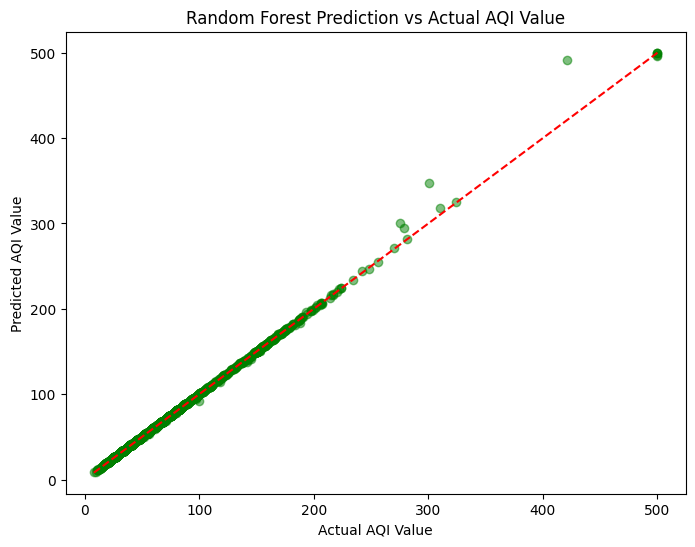

In [14]:
# Visualizing predicted vs actual AQI Value
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.5, color='g')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='r', linestyle='--')
plt.title('Random Forest Prediction vs Actual AQI Value')
plt.xlabel('Actual AQI Value')
plt.ylabel('Predicted AQI Value')
plt.show()

In [15]:
# Geographic Visualization of AQI across different locations
fig = px.scatter_geo(df, lat='lat', lon='lng', color='AQI Value', hover_name='AQI Value',
                     color_continuous_scale='Viridis', title="Geographic Distribution of AQI Values")
fig.show()

In this project, I compared two regression models, Linear Regression and Random Forest Regressor, to forecast air quality based on various pollutants like CO, Ozone, NO2, and PM2.5. After preprocessing the data and performing exploratory analysis, I trained both models and evaluated their performance using metrics such as Mean Absolute Error (MAE), RMSE, and R². The Random Forest model outperformed Linear Regression, demonstrating its ability to capture more complex, non-linear patterns in the data.